# ANALISIS CLUSTERING INDUSTRI KEHUTANAN (K-MEANS)


### Nama : Renata Yasmine Selomita
### NIM  : 202231059

### Mengimpor Library yang Dibutuhkan

In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

### Mengatur Opsi Tampilan Pandas

In [ ]:
pd.set_option('display.max_columns', None) #melihat semua kolom

### Menghubungkan Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import sys
sys.path.append('/content/drive/My Drive/LAPORAN MAGANG/')

Mounted at /content/drive


### Memuat Dataset

In [ ]:
file_path = '/content/drive/My Drive/LAPORAN MAGANG/cluster-kehutanan.csv'
data = pd.read_csv(file_path, sep=';', engine='python')
display(data.head())

,Provinsi,Nilai Eskpor 2024,Pemenuhan Bahan Baku 2024
0,Aceh,"0,00","0,00"
1,Sumatera Utara,"225954374,01","1680786,43"
2,Sumatera Barat,"57993,02","0,00"
3,Riau,"800507474,00","32033328,87"
4,Jambi,"109578914,89","4704651,91"


### Menetapkan Nama Kolom Dataset

In [ ]:
# Menambahkan nama kolom
data.columns = ['Provinsi', 'Nilai Ekspor Kehutanan 2024', 'Pemenuhan Bahan Baku 2024']
display(data.head())

,Provinsi,Nilai Ekspor Kehutanan 2024,Pemenuhan Bahan Baku 2024
0,Aceh,"0,00","0,00"
1,Sumatera Utara,"225954374,01","1680786,43"
2,Sumatera Barat,"57993,02","0,00"
3,Riau,"800507474,00","32033328,87"
4,Jambi,"109578914,89","4704651,91"


### Menampilkan Dimensi Dataset

In [ ]:
# Menampilkan jumlah baris dan kolom
print("Dimensi Dataset:")
data.shape

Dimensi Dataset:


(38, 3)

### Menampilkan Informasi Dataset dan Tipe Data

In [ ]:
# Menampilkan tipe data dan jumlah data yang tersedia di setiap kolom
print("\nInformasi Dataset:")
data.info()


Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 3 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Provinsi                     38 non-null     object
 1   Nilai Ekspor Kehutanan 2024  38 non-null     object
 2   Pemenuhan Bahan Baku 2024    38 non-null     object
dtypes: object(3)
memory usage: 1.0+ KB


### Membersihkan Kolom Numerik: Mengganti Koma dengan Titik

In [ ]:
# Mengganti koma (,) menjadi titik (.) pada kolom 'Nilai Ekspor 2020'
data['Nilai Ekspor Kehutanan 2024'] = data['Nilai Ekspor Kehutanan 2024'].str.replace(',', '.', regex=False)
# Mengganti koma (,) menjadi titik (.) pada kolom 'Nilai Ekspor 2021'
data['Pemenuhan Bahan Baku 2024'] = data['Pemenuhan Bahan Baku 2024'].str.replace(',', '.', regex=False)

# Menampilkan hasil setelah mengganti koma dengan titik
print("\nData Setelah Mengganti Koma dengan Titik:")
display(data.head())


Data Setelah Mengganti Koma dengan Titik:


,Provinsi,Nilai Ekspor Kehutanan 2024,Pemenuhan Bahan Baku 2024
0,Aceh,0.00,0.00
1,Sumatera Utara,225954374.01,1680786.43
2,Sumatera Barat,57993.02,0.00
3,Riau,800507474.00,32033328.87
4,Jambi,109578914.89,4704651.91


### Mengonversi Kolom Numerik ke Tipe Data Float

In [ ]:
# Mengonversi kolom menjadi tipe data float
data['Nilai Ekspor Kehutanan 2024'] = pd.to_numeric(data['Nilai Ekspor Kehutanan 2024'], errors='coerce')
data['Pemenuhan Bahan Baku 2024'] = pd.to_numeric(data['Pemenuhan Bahan Baku 2024'], errors='coerce')

# Menampilkan hasil setelah konversi
print("\nData Setelah Konversi Tipe Data:")
display(data.info())


Data Setelah Konversi Tipe Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 3 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Provinsi                     38 non-null     object 
 1   Nilai Ekspor Kehutanan 2024  38 non-null     float64
 2   Pemenuhan Bahan Baku 2024    38 non-null     float64
dtypes: float64(2), object(1)
memory usage: 1.0+ KB


None

### Memeriksa Nilai yang Hilang (Missing Values)

In [ ]:
# Menampilkan jumlah nilai kosong di setiap kolom
print("\nJumlah Missing Values:\n")
data.isnull().sum()


Jumlah Missing Values:



,0
Provinsi,0
Nilai Ekspor Kehutanan 2024,0
Pemenuhan Bahan Baku 2024,0


### Memeriksa Baris Duplikat

In [ ]:
duplicates = data.duplicated()
duplicate_count = duplicates.sum()
print(f"\nJumlah baris yang duplikat: {duplicate_count}")


Jumlah baris yang duplikat: 0


### Menampilkan Statistik Deskriptif

In [ ]:
print("\nStatistik Deskriptif untuk Variabel Numerik:\n")
data.describe()


Statistik Deskriptif untuk Variabel Numerik:



,Nilai Ekspor Kehutanan 2024,Pemenuhan Bahan Baku 2024
count,3.800000e+01,3.800000e+01
mean,3.313632e+08,1.721899e+06
std,9.328168e+08,5.616252e+06
min,0.000000e+00,0.000000e+00
25%,6.027287e+04,0.000000e+00
50%,2.675967e+07,2.355406e+04
75%,1.061365e+08,4.134274e+05
max,5.226699e+09,3.203333e+07


### Memastikan Tipe Numerik untuk Kolom Terpilih

In [ ]:
cols = ['Nilai Ekspor Kehutanan 2024', 'Pemenuhan Bahan Baku 2024']
data[cols] = data[cols].apply(pd.to_numeric, errors='coerce')

### Normalisasi Data

In [ ]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(data[cols]), columns=cols, index=data.index)

In [ ]:
# Menampilkan hasil setelah normalisasi
print("\nData Setelah Normalisasi:")
print(X_scaled)  # Menampilkan 5 baris pertama hasil normalisasi


Data Setelah Normalisasi:
    Nilai Ekspor Kehutanan 2024  Pemenuhan Bahan Baku 2024
0                     -0.359997                  -0.310708
1                     -0.114517                  -0.007419
2                     -0.359934                  -0.310708
3                      0.509684                   5.469540
4                     -0.240949                   0.538222
5                      1.284432                   2.212734
6                     -0.358733                  -0.309185
7                     -0.331180                  -0.262056
8                     -0.359924                  -0.310708
9                     -0.328389                  -0.310708
10                     5.318352                  -0.310708
11                     0.039409                  -0.283159
12                     1.317480                   0.292823
13                    -0.290061                  -0.309279
14                     1.652360                   0.437862
15                    -0.1387

### Visualisasi Distribusi Data: Sebelum dan Sesudah Normalisasi Data

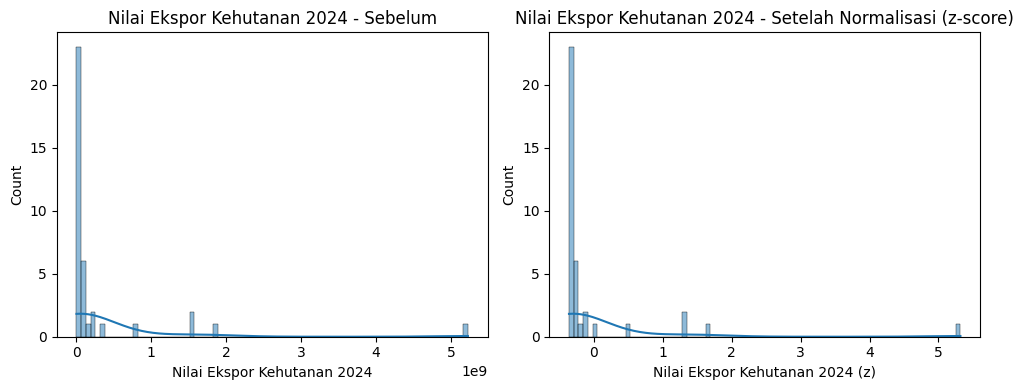

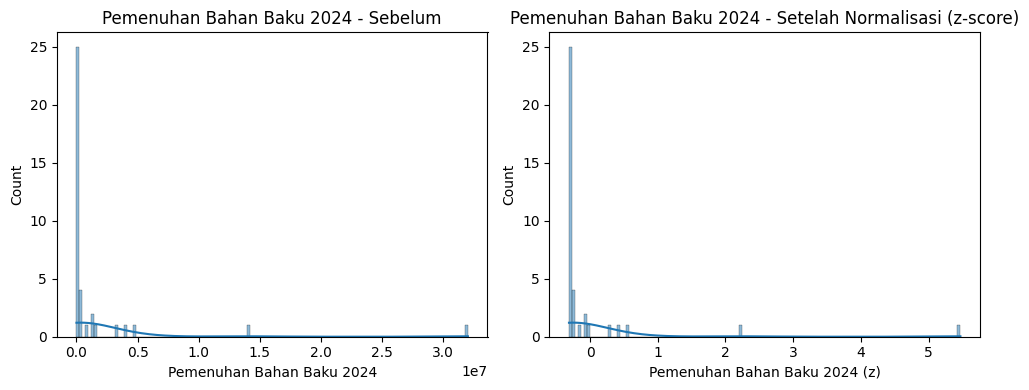

In [ ]:
# === 1) HISTOGRAM + KDE: Before vs After (per kolom) ===
for c in cols:
    fig, axes = plt.subplots(1, 2, figsize=(10,4))
    sns.histplot(data[c].dropna(), kde=True, ax=axes[0])
    axes[0].set_title(f'{c} - Sebelum')
    axes[0].set_xlabel(c)

    sns.histplot(X_scaled[c].dropna(), kde=True, ax=axes[1])
    axes[1].set_title(f'{c} - Setelah Normalisasi (z-score)')
    axes[1].set_xlabel(f'{c} (z)')
    plt.tight_layout()
    plt.show()

### Mempersiapkan Data untuk Clustering

In [ ]:
# --- Data hasil normalisasi ---
X = X_scaled[['Nilai Ekspor Kehutanan 2024', 'Pemenuhan Bahan Baku 2024']].dropna()

### Menghitung Cluster Menggunakan Metode Silhouette

In [ ]:
silhouette_scores = []
K_range = range(2, 12)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)
    print(f"k = {k} → Silhouette Score = {score:.4f}")

k = 2 → Silhouette Score = 0.8166
k = 3 → Silhouette Score = 0.8473
k = 4 → Silhouette Score = 0.8347
k = 5 → Silhouette Score = 0.8342
k = 6 → Silhouette Score = 0.7539
k = 7 → Silhouette Score = 0.6470
k = 8 → Silhouette Score = 0.6758
k = 9 → Silhouette Score = 0.6349
k = 10 → Silhouette Score = 0.5362
k = 11 → Silhouette Score = 0.5332


### Visualisasi Hasil Cluster

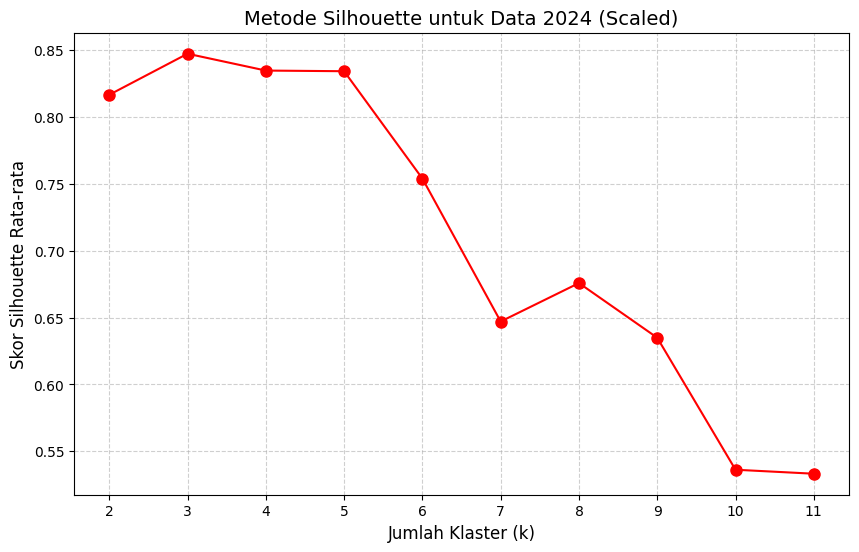

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(K_range, silhouette_scores, 'ro-', markerfacecolor='red', markersize=8)
plt.title(f'Metode Silhouette untuk Data 2024 (Scaled)', fontsize=14)
plt.xlabel('Jumlah Klaster (k)', fontsize=12)
plt.ylabel('Skor Silhouette Rata-rata', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(K_range)
plt.show()

### Menentukan Jumlah Cluster Optimal

In [ ]:
optimal_k = K_range[silhouette_scores.index(max(silhouette_scores))]
print(f"\nJumlah cluster optimal berdasarkan Silhouette Score = {optimal_k}")


Jumlah cluster optimal berdasarkan Silhouette Score = 3


### Menerapkan K-Means dengan Cluster Optimal

In [ ]:
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=50)
data['Cluster_Silhouette'] = kmeans.fit_predict(X)

# Menampilkan rata-rata per cluster dalam format DataFrame
cluster_means_df = data.groupby('Cluster_Silhouette')[['Nilai Ekspor Kehutanan 2024', 'Pemenuhan Bahan Baku 2024']].mean()

# Menampilkan rata-rata per cluster yang sudah lebih terstruktur
print("\nRata-rata per cluster:")
display(cluster_means_df)


Rata-rata per cluster:


,Nilai Ekspor Kehutanan 2024,Pemenuhan Bahan Baku 2024
Cluster_Silhouette,,
0,1.157070e+09,2.300894e+07
1,1.443132e+08,5.546935e+05
2,5.226699e+09,0.000000e+00


### Tabel Hasil Clusterisasi

In [ ]:
# === Tabel hasil clusterisasi ===
tabel_cluster = data[['Provinsi', 'Nilai Ekspor Kehutanan 2024', 'Pemenuhan Bahan Baku 2024', 'Cluster_Silhouette']].copy()

# Urutkan berdasarkan cluster
tabel_cluster = tabel_cluster.sort_values(by='Cluster_Silhouette').reset_index(drop=True)

print("\nTabel Hasil Clusterisasi (Silhouette Optimal = 3):")
display(tabel_cluster)

# Simpan ke file CSV kalau mau diekspor
tabel_cluster.to_csv("hasil_cluster_silhouette.csv", index=False)


Tabel Hasil Clusterisasi (Silhouette Optimal = 3):


,Provinsi,Nilai Ekspor Kehutanan 2024,Pemenuhan Bahan Baku 2024,Cluster_Silhouette
0,Riau,8.005075e+08,32033328.87,0
1,Sumatera Selatan,1.513633e+09,13984560.56,0
2,Sumatera Utara,2.259544e+08,1680786.43,1
3,Aceh,0.000000e+00,0.00,1
4,Sumatera Barat,5.799302e+04,0.00,1
5,Jambi,1.095789e+08,4704651.91,1
6,Bengkulu,1.163635e+06,8436.27,1
7,Lampung,2.652467e+07,269621.90,1
8,Kepulauan Bangka Belitung,6.711242e+04,0.00,1
9,Kepulauan Riau,2.909424e+07,0.00,1


### Meampilkan Centroid Untuk Setiap Cluster

In [ ]:
# Menampilkan centroid untuk setiap cluster dalam format DataFrame
centroid_df = pd.DataFrame(kmeans.cluster_centers_, columns=X.columns)

# Menambahkan label untuk setiap cluster
centroid_df.index = [f'Cluster {i}' for i in range(centroid_df.shape[0])]

# Menampilkan centroid yang sudah lebih terstruktur
print("\nCentroid per cluster:")
display(centroid_df)



Centroid per cluster:


,Nilai Ekspor Kehutanan 2024,Pemenuhan Bahan Baku 2024
Cluster 0,0.897058,3.841137
Cluster 1,-0.203213,-0.210616
Cluster 2,5.318352,-0.310708


### Visualisasi Hasil Clustering

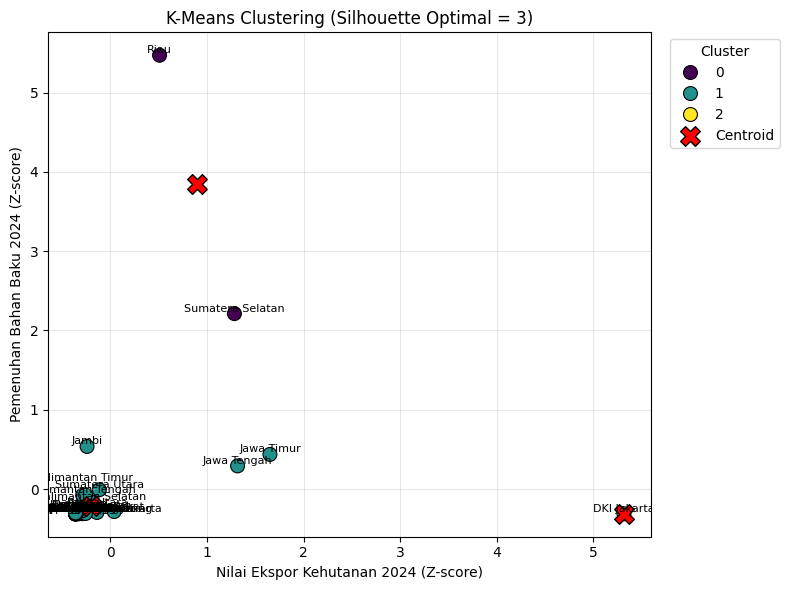

In [ ]:
# --- Visualisasi hasil clustering (dengan label provinsi) ---
plt.figure(figsize=(8, 6))

ax = sns.scatterplot(
    x=X['Nilai Ekspor Kehutanan 2024'],
    y=X['Pemenuhan Bahan Baku 2024'],
    hue=data['Cluster_Silhouette'],
    palette='viridis',
    s=100,
    edgecolor='black'
)

# plot centroid
centers = kmeans.cluster_centers_
plt.scatter(
    centers[:, 0], centers[:, 1],
    c='red', s=200, marker='X',
    edgecolors='black', label='Centroid'
)

# tambahkan label nama provinsi di tiap titik
# asumsinya data['Provinsi'] ada dan urutannya sama dengan X
for i, prov in enumerate(data['Provinsi']):
    plt.text(
        X['Nilai Ekspor Kehutanan 2024'].iloc[i],
        X['Pemenuhan Bahan Baku 2024'].iloc[i],
        str(prov),
        fontsize=8,
        ha='center',
        va='bottom',   # kasih offset dikit biar gak nabrak marker
        clip_on=True
    )

plt.title(f'K-Means Clustering (Silhouette Optimal = {optimal_k})')
plt.xlabel('Nilai Ekspor Kehutanan 2024 (Z-score)')
plt.ylabel('Pemenuhan Bahan Baku 2024 (Z-score)')
plt.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()